In [1]:
| Feature                       | K-Means                                   | DBSCAN                                     |
| ----------------------------- | ----------------------------------------- | ------------------------------------------ |
| **Type of Algorithm**         | Centroid-based clustering                 | Density-based clustering                   |
| **Number of Clusters**        | Must be specified (K value)               | Automatically determines clusters          |
| **Shape of Clusters**         | Works best for spherical (round) clusters | Can detect arbitrary (any) shaped clusters |
| **Handling Noise/Outliers**   | Poor (sensitive to outliers)              | Strong (identifies noise points)           |
| **Distance Measure**          | Typically Euclidean distance              | Uses density (ε radius and min points)     |
| **Initialization Needed**     | Yes (random centroids)                    | No random initialization                   |
| **Performance on Large Data** | Fast and efficient                        | Slower for very large datasets             |
| **Cluster Size Sensitivity**  | Works best when clusters are similar size | Can handle clusters of different sizes     |
| **Interpretability**          | Easy to understand                        | Slightly more complex                      |
| **Use Case Type**             | Well-separated data                       | Noisy and complex data                     |


SyntaxError: invalid syntax (4095787091.py, line 1)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# load mpg dataset
data=sns.load_dataset('mpg')
data = data[['cylinders','displacement','horsepower','weight','acceleration']]

In [7]:
data=data.dropna()
data.isna().sum()

cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
dtype: int64

In [8]:
# Scaled the data
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler()

In [10]:
scaler.fit_transform(data)

array([[1.        , 0.61757106, 0.45652174, 0.5361497 , 0.23809524],
       [1.        , 0.72868217, 0.64673913, 0.58973632, 0.20833333],
       [1.        , 0.64599483, 0.56521739, 0.51686986, 0.17857143],
       ...,
       [0.2       , 0.17312661, 0.20652174, 0.19336547, 0.21428571],
       [0.2       , 0.13436693, 0.17934783, 0.2869294 , 0.63095238],
       [0.2       , 0.13178295, 0.19565217, 0.31386447, 0.67857143]],
      shape=(392, 5))

In [11]:
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled

,cylinders,displacement,horsepower,weight,acceleration
0,1.0,0.617571,0.456522,0.536150,0.238095
1,1.0,0.728682,0.646739,0.589736,0.208333
2,1.0,0.645995,0.565217,0.516870,0.178571
3,1.0,0.609819,0.565217,0.516019,0.238095
4,1.0,0.604651,0.510870,0.520556,0.148810
...,...,...,...,...,...
387,0.2,0.186047,0.217391,0.333711,0.452381
388,0.2,0.074935,0.032609,0.146583,0.988095
389,0.2,0.173127,0.206522,0.193365,0.214286
390,0.2,0.134367,0.179348,0.286929,0.630952


In [12]:
# Convert Data in 2d using PCA
from sklearn.decomposition import PCA

In [13]:
pca = PCA(n_components=2)
pca_df = pca.fit_transform(data_scaled)
pca_df

array([[ 6.17213583e-01, -6.01814453e-02],
       [ 7.71073334e-01, -1.32589783e-01],
       [ 6.73646884e-01, -1.53373805e-01],
       [ 6.44344658e-01, -1.03978179e-01],
       [ 6.39947233e-01, -1.61541653e-01],
       [ 1.03459674e+00, -2.13903891e-01],
       [ 1.12310157e+00, -3.02910024e-01],
       [ 1.09520737e+00, -3.24353214e-01],
       [ 1.13227174e+00, -2.55416483e-01],
       [ 9.24103622e-01, -3.17906006e-01],
       [ 8.24116795e-01, -2.24314669e-01],
       [ 7.75449633e-01, -3.11556389e-01],
       [ 8.36075516e-01, -1.94982876e-01],
       [ 9.68624608e-01, -3.53593647e-01],
       [-3.77880354e-01, -1.34045691e-01],
       [ 3.50190461e-02,  3.01559889e-02],
       [ 3.30792554e-02,  2.21624238e-02],
       [-1.76674388e-02,  5.73269181e-02],
       [-4.36788768e-01, -1.66632816e-01],
       [-6.20637107e-01,  2.01916599e-01],
       [-3.87835314e-01,  3.19626706e-02],
       [-3.83152290e-01, -1.46978408e-01],
       [-4.16050483e-01, -5.95712171e-03],
       [-3.

In [14]:
pca_df = pd.DataFrame(pca_df, columns=['A','B'])
pca_df.head(2)

,A,B
0,0.617214,-0.060181
1,0.771073,-0.132590


<Axes: title={'center': '2D Representations of Data'}, xlabel='A', ylabel='B'>

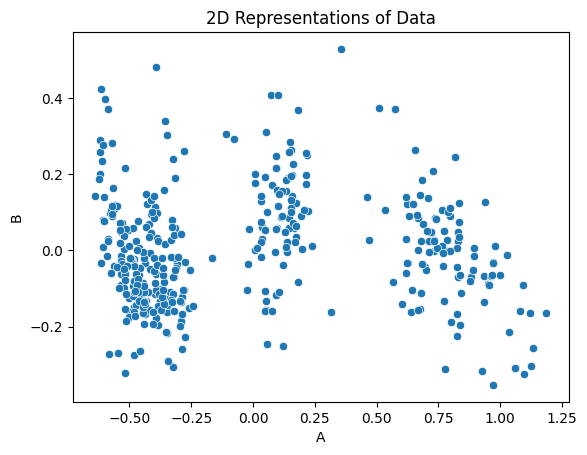

In [15]:
# plot the 2d representation of data_scaled
plt.title("2D Representations of Data")
sns.scatterplot(x='A',y='B', data=pca_df)

In [16]:
# import DBScan
from sklearn.cluster import DBSCAN

In [17]:
# Implement DBSCAN
#create a model of dbscan
dbscan = DBSCAN( eps=0.2, min_samples=5)

In [18]:
clusters=dbscan.fit_predict(pca_df)
clusters

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
        0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  1,  1,  1,
        1,  0,  1,  1,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,
        0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,
        0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  0,  1,  1,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  0,  0,
        0,  0,  1,  1,  1

In [19]:
pca_df['clstr'] = clusters
pca_df

,A,B,clstr
0,0.617214,-0.060181,0
1,0.771073,-0.132590,0
2,0.673647,-0.153374,0
3,0.644345,-0.103978,0
4,0.639947,-0.161542,0
...,...,...,...
387,-0.316001,-0.051247,1
388,-0.616682,0.423980,1
389,-0.344032,-0.291173,1
390,-0.408270,0.102095,1


<Axes: title={'center': '2D Representations of Data'}, xlabel='A', ylabel='B'>

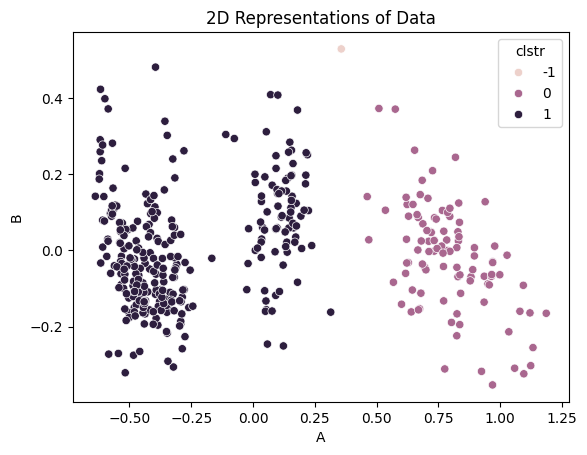

In [20]:
plt.title("2D Representations of Data")
sns.scatterplot(x='A',y='B', data=pca_df,hue='clstr')

<Axes: title={'center': '2D Representations of Data'}, xlabel='A', ylabel='B'>

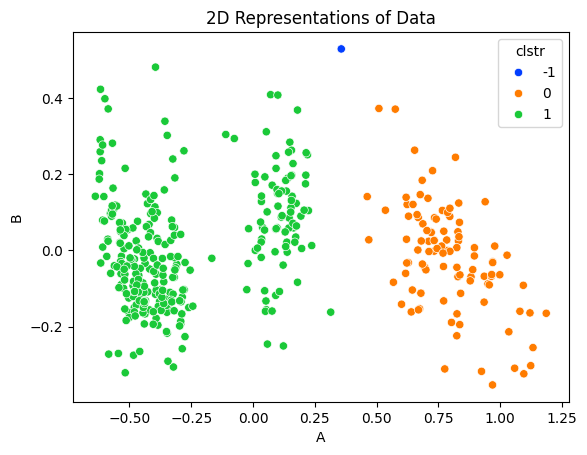

In [21]:
plt.title("2D Representations of Data")
sns.scatterplot(x='A',y='B', data=pca_df, hue='clstr', palette='bright')

In [22]:
data = pd.read_csv(r"C:\Users\mingm\Videos\red wine\wineQualityReds.csv")
data.head(2)

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


In [23]:
data = data.drop('Unnamed: 0', axis=1)
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [24]:
data

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [25]:
# drop 'quality'
df= data.copy()

In [26]:
data = data.drop('quality', axis=1)
data.head(2)

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8


<Axes: >

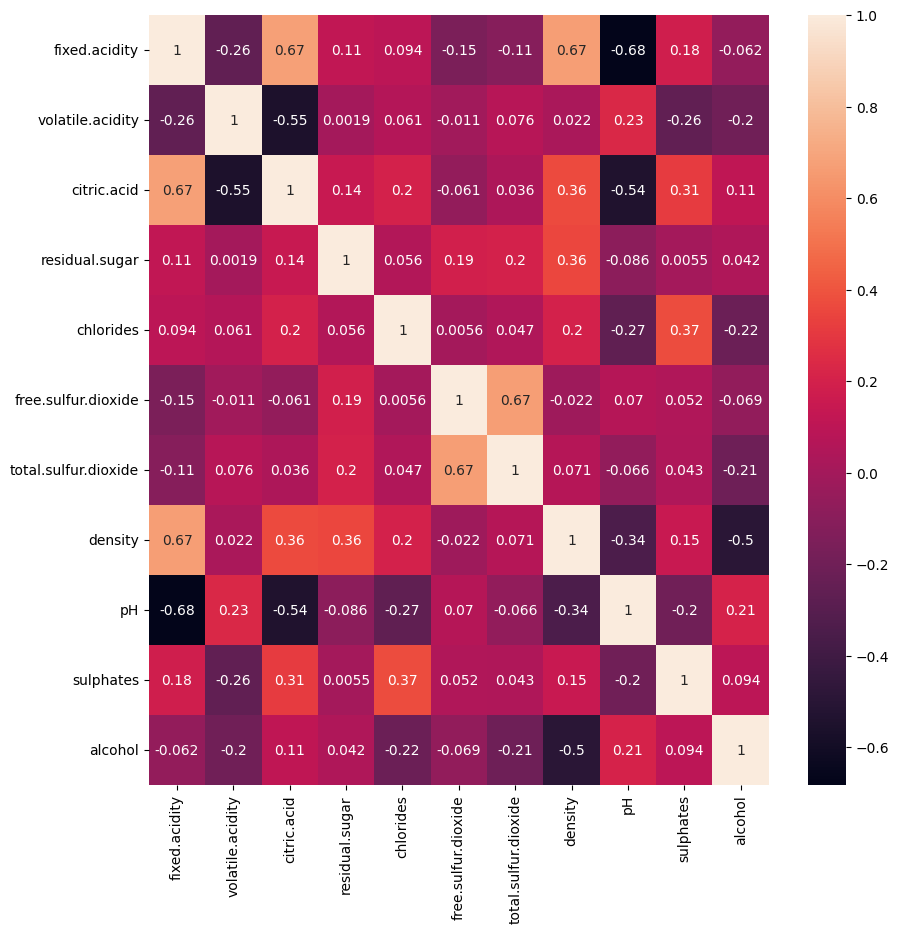

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True)

In [28]:
scaler = MinMaxScaler()

In [29]:
scaler.fit_transform(data)

array([[0.24778761, 0.39726027, 0.        , ..., 0.60629921, 0.13772455,
        0.15384615],
       [0.28318584, 0.52054795, 0.        , ..., 0.36220472, 0.20958084,
        0.21538462],
       [0.28318584, 0.43835616, 0.04      , ..., 0.40944882, 0.19161677,
        0.21538462],
       ...,
       [0.15044248, 0.26712329, 0.13      , ..., 0.53543307, 0.25149701,
        0.4       ],
       [0.11504425, 0.35958904, 0.12      , ..., 0.65354331, 0.22754491,
        0.27692308],
       [0.12389381, 0.13013699, 0.47      , ..., 0.51181102, 0.19760479,
        0.4       ]], shape=(1599, 11))

In [30]:
import pandas as pd
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled.head(2)

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,0.247788,0.397260,0.0,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
1,0.283186,0.520548,0.0,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385


# Decompose the data

In [33]:
pca_df = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(pca_df, columns=['A','B'])
pca_df.head(2)

,A,B
0,-0.271839,-0.195125
1,-0.225848,-0.258617


# Visualize the Decomposed Data

<Axes: title={'center': '2D Representation of Wine Dataset'}, xlabel='A', ylabel='B'>

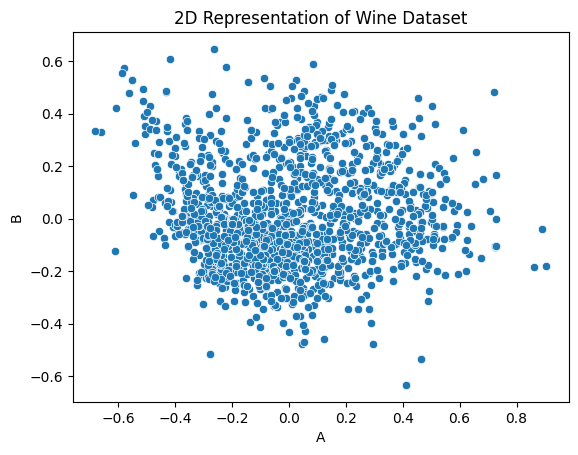

In [37]:
plt.title("2D Representation of Wine Dataset")
sns.scatterplot(x='A',y='B',data = pca_df)

# Clustering with Kmeans Clustering

In [38]:
from sklearn.cluster import KMeans

In [39]:
wcss=[]
for k in range(2,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)

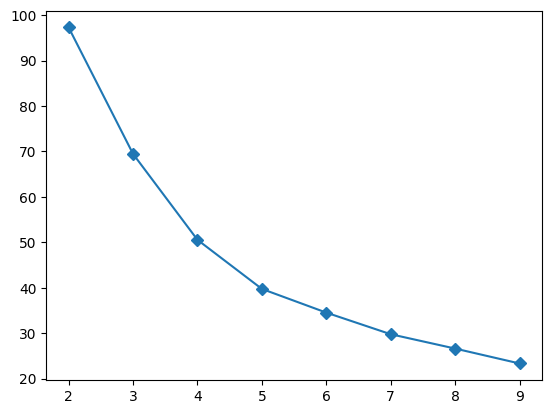

In [40]:
# Plot Wcss and Range
plt.plot(range(2,10), wcss,marker='D')

In [48]:
# Nclusters = 4
k = KMeans(n_clusters = 4)
k.fit(pca_df)
pca_df['labels'] = k.labels_

<Axes: xlabel='A', ylabel='B'>

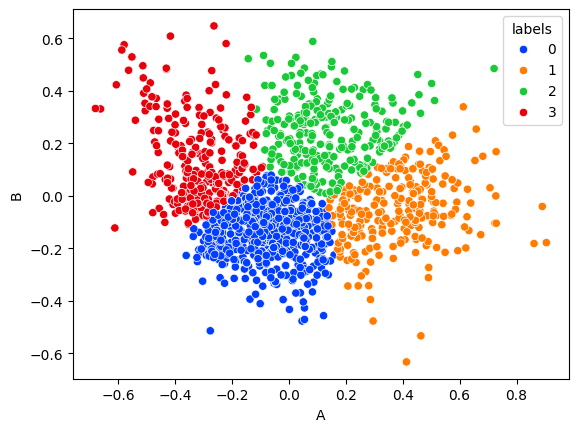

In [50]:
sns.scatterplot(x='A', y='B', data=pca_df, hue='labels',palette='bright')

In [51]:
#n_cluster = 5
k5 = KMeans(n_clusters=5)

In [52]:
k5.fit(pca_df)
pca_df['labels_5'] = k.labels_

In [53]:
pca_df

,A,B,,labels,labels_5
0,-0.271839,-0.195125,2,0,0
1,-0.225848,-0.258617,2,0,0
2,-0.187260,-0.179955,2,0,0
3,0.422279,-0.031881,0,1,1
4,-0.271839,-0.195125,2,0,0
...,...,...,...,...,...
1594,-0.337500,-0.031716,1,3,3
1595,-0.344092,0.038897,1,3,3
1596,-0.246771,0.046616,1,3,3
1597,-0.338070,-0.065408,1,3,3


<Axes: title={'center': 'DAta with Cluster 5'}, xlabel='A', ylabel='B'>

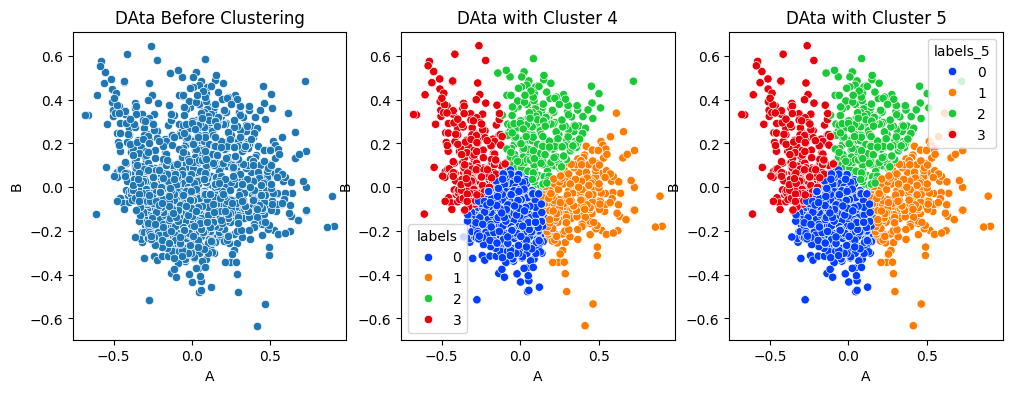

In [60]:
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].set_title("DAta Before Clustering")
axes[1].set_title("DAta with Cluster 4")
axes[2].set_title("DAta with Cluster 5")
sns.scatterplot(x='A',y='B',data = pca_df, ax=axes[0])
sns.scatterplot(x='A',y='B',data=pca_df, hue='labels',palette='bright', ax=axes[1])
sns.scatterplot(x='A',y='B',data=pca_df,hue='labels_5',palette='bright', ax=axes[2])

In [62]:
data['cluster_4'] = pca_df['labels']
data['cluster_5'] = pca_df['labels_5']

In [63]:
data.groupby('cluster_4')['citric.acid'].agg(['min','max','mean'])

,min,max,mean
cluster_4,,,
0,0.00,0.56,0.178100
1,0.20,1.00,0.506187
2,0.24,0.69,0.435000
3,0.00,0.66,0.084116


In [66]:
data.groupby('cluster_5')[['alcohol','residual.sugar']].agg(['min','max','mean'])

alcohol                  residual.sugar                
              min   max       mean            min   max      mean
cluster_5                                                        
0             8.7  11.6   9.716053            1.2  13.4  2.481443
1             8.4  13.0  10.016945            1.4  15.5  2.965385
2             9.6  14.9  11.507419            0.9  12.9  2.518871
3             9.4  14.0  11.275831            1.2   8.3  2.273794

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [68]:
data = pd.read_csv(r"C:\Users\mingm\Videos\red wine\wineQualityReds.csv")
data.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [69]:
X = data.drop('quality', axis=1)

In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
dbscan = DBSCAN(eps=1.5, min_samples=5)   # you can tune eps
labels = dbscan.fit_predict(X_scaled)

In [72]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4,  5])

In [73]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_result, columns=['A', 'B'])
pca_df['labels'] = labels

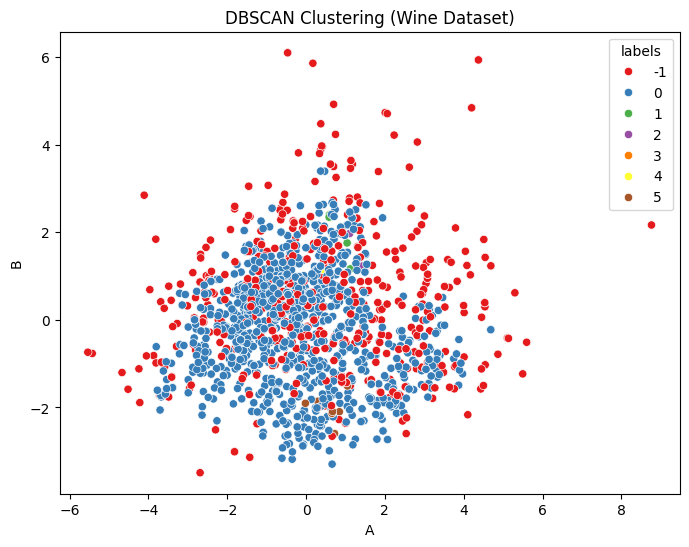

In [74]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='A', y='B', data=pca_df, hue='labels', palette='Set1')
plt.title("DBSCAN Clustering (Wine Dataset)")
plt.show()